# Weather - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

**Open-Meteo.** A free weather service built for programs rather than people: give it a
latitude, longitude and date range, and it returns decades of daily weather. No account, no
key, no cost. Think of it as: *"the weather history of any point on Earth, as a table."*

- **Explore it in a browser:** <https://open-meteo.com/en/docs/historical-weather-api>
  (a live form: type a city, tick *temperature* and *dew point*, and it builds the exact web
  address that returns the data)
- Research-grade source behind it (ERA5): <https://cds.climate.copernicus.eu/>

> Why weather at all? **Absolute humidity** is the established driver of influenza
> seasonality (Shaman & Kohn 2009; Shaman et al. 2010, 2012). Weather does not count cases;
> it shifts the conditions for transmission.


## Step 1: pull the weather

> *Using the Open-Meteo historical archive API (free, no key), pull daily mean*
> *temperature and dew point for Rotterdam (51.9225,4.47917) from 2022 to now. Return a*
> *tidy DataFrame and report the date range.*


In [1]:
import pandas as pd, json, urllib.request

LAT, LON = 51.9225, 4.47917  # Rotterdam, NL
START, END = '2022-01-01', '2026-07-21'

url = ('https://archive-api.open-meteo.com/v1/archive'
       f'?latitude={LAT}&longitude={LON}&start_date={START}&end_date={END}'
       '&daily=temperature_2m_mean,dew_point_2m_mean&timezone=auto')

req = urllib.request.Request(url, headers={'User-Agent': 'SISMID2026-course/1.0'})
data = json.loads(urllib.request.urlopen(req, timeout=120).read())['daily']

wx = pd.DataFrame({
    'date': pd.to_datetime(data['time']),
    'temp_c': data['temperature_2m_mean'],
    'dewpoint_c': data['dew_point_2m_mean'],
})

print(f"{len(wx)} days, {wx['date'].min().date()} to {wx['date'].max().date()}")
wx.head()


1663 days, 2022-01-01 to 2026-07-21


,date,temp_c,dewpoint_c
0,2022-01-01,11.8,9.9
1,2022-01-02,11.5,9.0
2,2022-01-03,9.1,6.6
3,2022-01-04,6.9,4.9
4,2022-01-05,4.9,1.2


## Step 2: compute absolute humidity

> *Compute absolute humidity in g/m^3 from temperature T and dew point Td:*
> *e = 6.112 * exp(17.67*Td/(Td+243.5)); AH = 216.7 * e / (T+273.15). Resample to weekly*
> *and plot it, then plot the mean AH by calendar month.*

**Your check:** does AH bottom out in winter? That is the Shaman result: low absolute
humidity precedes influenza season.


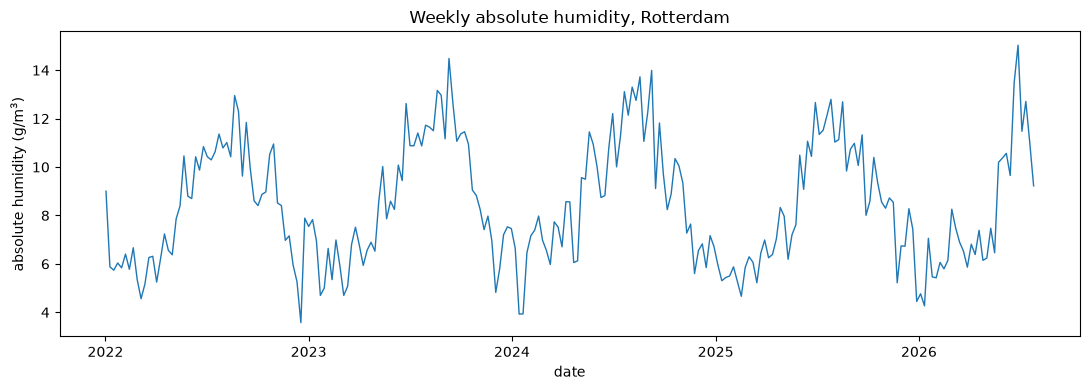

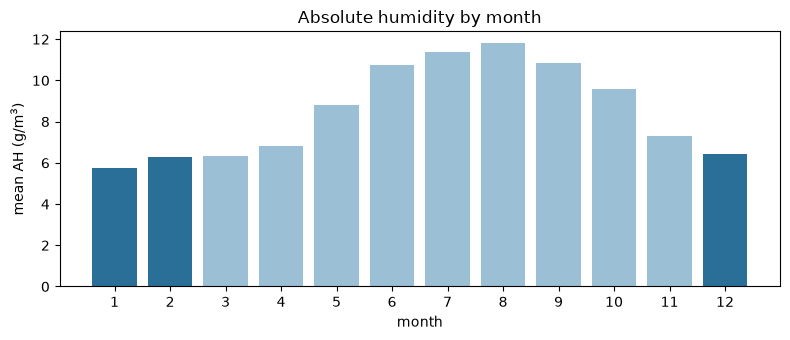

driest months: {1: 5.73, 2: 6.29, 3: 6.34}


In [2]:
import numpy as np
import matplotlib.pyplot as plt

e = 6.112 * np.exp(17.67 * wx['dewpoint_c'] / (wx['dewpoint_c'] + 243.5))
wx['abs_humidity_g_m3'] = 216.7 * e / (wx['temp_c'] + 273.15)

wk = wx.set_index('date')['abs_humidity_g_m3'].resample('W').mean().reset_index()
plt.figure(figsize=(11, 4))
plt.plot(wk['date'], wk['abs_humidity_g_m3'], lw=1)
plt.ylabel('absolute humidity (g/m$^3$)'); plt.xlabel('date')
plt.title('Weekly absolute humidity, Rotterdam')
plt.tight_layout(); plt.show()

wx['month'] = wx['date'].dt.month
monthly = wx.groupby('month')['abs_humidity_g_m3'].mean()
plt.figure(figsize=(8, 3.5))
plt.bar(monthly.index, monthly.values,
        color=['#2A6F97' if m in (12, 1, 2) else '#9bbfd4' for m in monthly.index])
plt.xticks(range(1, 13)); plt.xlabel('month'); plt.ylabel('mean AH (g/m$^3$)')
plt.title('Absolute humidity by month')
plt.tight_layout(); plt.show()
print('driest months:', monthly.nsmallest(3).round(2).to_dict())


## Step 3: sanity-check and save

> *Report the date range, missing values, and the AH range, then save a tidy CSV.*


In [3]:
print('date range :', wx['date'].min().date(), 'to', wx['date'].max().date())
print('missing    :')
print(wx[['temp_c', 'dewpoint_c', 'abs_humidity_g_m3']].isna().sum())
print('AH range   :', round(wx['abs_humidity_g_m3'].min(), 2), 'to',
      round(wx['abs_humidity_g_m3'].max(), 2), 'g/m^3')

wx_tidy = wx[['date', 'temp_c', 'dewpoint_c', 'abs_humidity_g_m3']]
wx_tidy.to_csv('weather_absolute_humidity.csv', index=False)
print('saved weather_absolute_humidity.csv')


date range : 2022-01-01 to 2026-07-21
missing    :
temp_c               0
dewpoint_c           0
abs_humidity_g_m3    0
dtype: int64
AH range   : 1.98 to 16.95 g/m^3
saved weather_absolute_humidity.csv


## Reflection

- Weather is a **modulator**, not a case count.
- **Stretch:** swap in a tropical city and compare the AH cycle.
